# Homework — Wine Classification with Cross-Validation

## Objective

In this homework, you will:

1. Use **cross-validation (CV)** to select the best value of **k** for KNN  
2. Plot **training accuracy** and **validation accuracy** for different k values  
3. Identify regions of **overfitting** and **underfitting**  
4. Compare the best k from the plot and from cross-validation  

---

## Important Rules

- Use only **odd values of k** (3, 5, ..., 99)
- Use **5-fold cross-validation**
- Do NOT use the test set during model selection
- The test set is used only once at the end


## 1) Import libraries

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2) Load dataset (provided)

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)



## 3) Train/Test Split (TODO)

Requirements:
- test_size = 0.20
- random_state = 42
- stratify = y


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (142, 13)
Test size: (36, 13)



## 4) Compute Training and Validation Accuracy for Different k (TODO)

Requirements:
- Use odd k values from 3 to 99
- Compute training accuracy
- Compute 5-fold CV validation accuracy
- Store results in lists


In [20]:
# TODO: your code here

k_values = range(3, 100, 2)
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_train = knn.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_accuracies.append(train_acc)

    # validation accuracy using 5-fold
    cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    val_acc = cv_scores.mean()
    val_accuracies.append(val_acc)

    print(f"k={k}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


k=3: Train Acc=0.8239, Val Acc=0.6690
k=5: Train Acc=0.7817, Val Acc=0.7108
k=7: Train Acc=0.7887, Val Acc=0.6968
k=9: Train Acc=0.7676, Val Acc=0.6975
k=11: Train Acc=0.7254, Val Acc=0.7047
k=13: Train Acc=0.7394, Val Acc=0.6906
k=15: Train Acc=0.7254, Val Acc=0.7047
k=17: Train Acc=0.7113, Val Acc=0.6909
k=19: Train Acc=0.7113, Val Acc=0.7192
k=21: Train Acc=0.7183, Val Acc=0.7049
k=23: Train Acc=0.7183, Val Acc=0.7264
k=25: Train Acc=0.7113, Val Acc=0.7192
k=27: Train Acc=0.7042, Val Acc=0.7264
k=29: Train Acc=0.7324, Val Acc=0.7121
k=31: Train Acc=0.7324, Val Acc=0.7121
k=33: Train Acc=0.7324, Val Acc=0.7049
k=35: Train Acc=0.7394, Val Acc=0.7049
k=37: Train Acc=0.7324, Val Acc=0.7118
k=39: Train Acc=0.7042, Val Acc=0.7049
k=41: Train Acc=0.7113, Val Acc=0.7261
k=43: Train Acc=0.7113, Val Acc=0.7190
k=45: Train Acc=0.7113, Val Acc=0.7192
k=47: Train Acc=0.7254, Val Acc=0.7121
k=49: Train Acc=0.7324, Val Acc=0.7052
k=51: Train Acc=0.7324, Val Acc=0.7123
k=53: Train Acc=0.7254, Val A


## 5) Plot Training vs Validation Accuracy (TODO)

Plot both curves on the same figure.


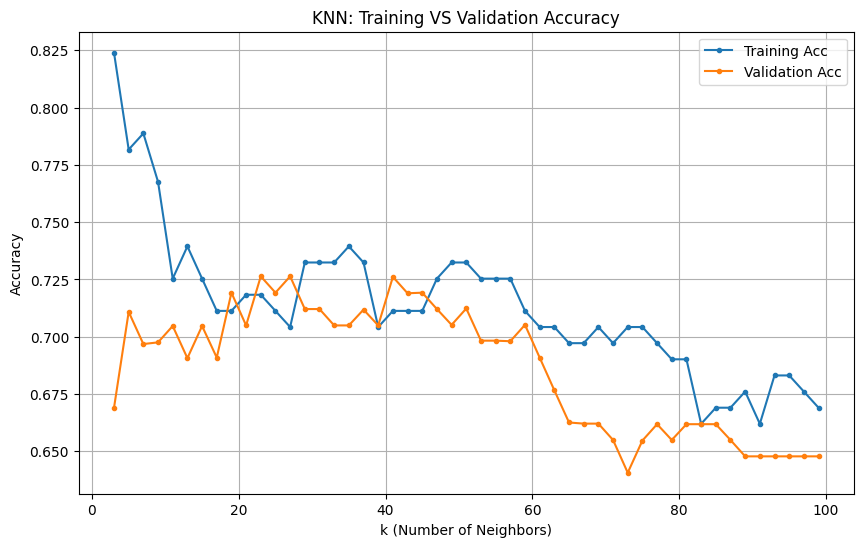

In [17]:
# TODO: your plot here

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Training Acc', marker='.')
plt.plot(k_values, val_accuracies, label='Validation Acc', marker='.')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Training VS Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 6) Select Best k Using Cross-Validation (TODO)

Find the k with the highest mean validation accuracy.


In [18]:
# TODO: find best_k
best_val_acc = max(val_accuracies)
best_k_index = val_accuracies.index(best_val_acc)
best_k = k_values[best_k_index]

print(f"Best k based on Cross Validation: k={best_k}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Best k based on Cross Validation: k=23
Best Validation Accuracy: 0.7264



## 7) Final Test Evaluation (TODO)

Train a final model using best_k.
Evaluate on the test set (only once).


In [19]:
# TODO: final model evaluation
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

y_pred_test = final_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Final Test Accuracy with k={best_k}: {test_accuracy:.4f}")

Final Test Accuracy with k=23: 0.7778



---

## 8) Reflection Questions (Answer in Markdown)

1. Which region of the graph shows **overfitting**? Why?
2. Which region shows **underfitting**? Why?
3. What is the best **k**?
4. What is the test accuracy of the final model?


#1. Based on the graph, the region with small k values (**example: k=3 to k=9**) shows some overfitting. Training accuracy is high (*around 82%*) but validation accuracy is much lower (*around 67%*).

#2. Based on the graph, the region with large k values (**example: k > 59**) shows underfitting in both training and validation accuracies. Both drop and converge to a lower value (*around 65%*) meaning the model has high bias.

#3. The **best_k** found via 5-fold cross-validation is **k=23**.

#4. The Test accuracy for the final model is **0.7778 (77.78%)**.